<a href="https://colab.research.google.com/github/SIDDH4RTH245/data-science-daily-journey/blob/main/machine-learning/model-interpretability/titanic-feature-importance/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df = df.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)

df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


/tmp/ipython-input-3866794364.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-3866794364.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [3]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [4]:
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df


,Feature,Importance
5,Sex_male,0.273316
4,Fare,0.272058
1,Age,0.252745
0,Pclass,0.078616
2,SibSp,0.052192
3,Parch,0.038490
7,Embarked_S,0.023095
6,Embarked_Q,0.009488


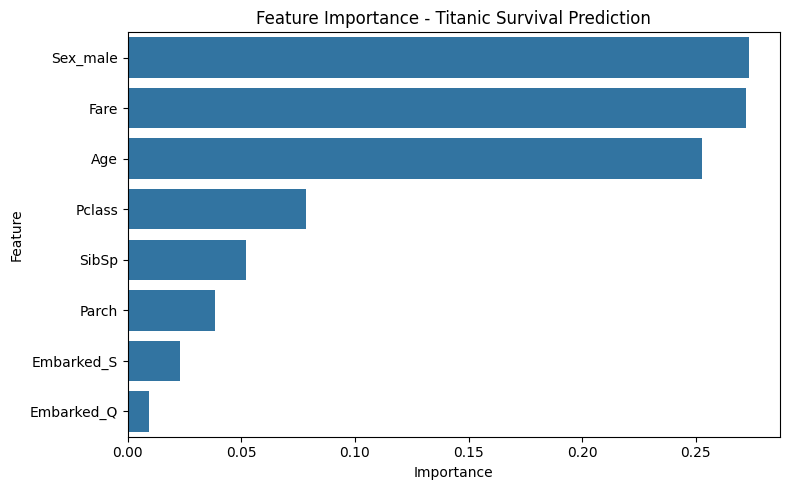

In [6]:
import os

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df
)

plt.title("Feature Importance - Titanic Survival Prediction")
plt.tight_layout()

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

plt.savefig("images/feature_importance.png")
plt.show()

## Key Insights

- Sex and Pclass are highly influential features.
- Age also significantly impacts survival probability.
- Feature importance helps interpret model decisions.
